# Marine 5-Day Forecast — Real 31-Parameter EMS Data (11-Model Comparison)

This notebook applies 11 of the 12-model suite from `Marine_Forecast_PyTorch_NBEATS_NHiTS.ipynb`
(Gaussian Process dropped -- see §16)
to **real(istic) EMS simulator data** instead of the hand-generated synthetic dataset:
`Simulation_30days_Data_31parameters.xlsx` — 30 days at **1-minute** resolution, 31 raw
sensor parameters, sourced from an actual marine Environmental Monitoring System (EMS)
data model.

## What's different from the synthetic-data notebook

1. **Duplicate collapse** (per `31_parameter_model_assignment.txt`): 6 of the 31 raw
   parameters are near-perfect linear duplicates of another parameter already in the
   set (verified below: all r ≥ 0.998 after resampling) — `windChillTemperature`
   (≡ `airTemperature`), `tidePressure`/`waterPressure`/`waterLevel` (≡ `tideLevel` via
   the hydrostatic relationship), `waterTemperature_WQ` (≡ `waterTemperature`,
   duplicate sensor), and `maxWaveHeight` (≡ `significantWaveHeight` via the Rayleigh
   wave-height distribution). These are **not modeled**; instead a simple linear fit
   (slope + intercept, R² ≥ 0.995 for all 6) reconstructs them from their kept twin.
2. **Three circular parameters**, not one: `windDirection`, `currentDirection`, and
   `compass` (platform heading) all need sin/cos encoding, not just wind direction.
3. **A categorical target**: `precipitationType` (NONE/DRIZZLE/RAIN) can't enter a
   regression model or a Pearson correlation matrix — handled separately by an XGBoost
   multiclass classifier (§ near the end).
4. **Resampled to 10-minute resolution** (from 1-minute): minute-level sensor noise has
   no multi-hour-ahead predictability, and 1-minute direct-multi-horizon output layers
   would be 10× larger for no benefit. 10-min averaging also matches a reporting cadence
   already present in the raw data (`tenMinuteAvgVisibility`).
5. **Lookback 2 days / horizon 48 hours** at 10-minute steps (LOOKBACK=288, HORIZON=288)
   — *not* the 5-day horizon the synthetic notebook used. With only 30 days of real data
   total, a 5-day horizon leaves too few non-overlapping training cycles to learn
   reliably (see §3); 48h keeps a 14:1 train:horizon ratio, matching the literature's
   recommended proportions.

**No hand-assignment of "this block gets LSTM, that block gets XGBoost"** the way the
assignment doc's simplified heuristic suggests — instead, exactly as in the synthetic
notebook, all 11 models are trained on all 24 numeric target channels (+6 derived via
linear reconstruction, +1 categorical via a separate classifier = 31), and the
**empirical per-parameter ranking + 2-model ensemble search** (already built and
validated) decides what's actually best, parameter by parameter. The assignment doc's
correlation analysis remains valuable — it explains *why* certain parameters cluster
and predicts which models should benefit from cross-parameter structure (TSMixer,
iTransformer, TiDE) versus which don't need it (DLinear, PatchTST, XGBoost) — but the
empirical results are what this notebook trusts over the heuristic.

Environment: conda env `marinepred` (PyTorch 2.12 CPU + XGBoost).

## 0. Setup

In [1]:
import os, time, json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, classification_report

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IMPORTANT: this machine reports 24 CPU threads, but PyTorch's recurrent (LSTM) ops are
# dominated by many tiny sequential per-timestep matmuls -- at this notebook's much longer
# long lookback windows, 24-way thread oversubscription on those tiny ops measured ~4x SLOWER
# than a modest thread count (111s/epoch at 24 threads vs 27s/epoch at 8, profiled directly
# on this machine). Capping threads is a strict win here, not a tradeoff.
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| device:", device, "| XGBoost:", xgb.__version__,
      "| torch threads:", torch.get_num_threads())


PyTorch: 2.12.1+cpu | device: cpu | XGBoost: 3.2.0 | torch threads: 8


## 1. Load real EMS data and inspect duplicate-collapse claims

Loads from `ems_10min_resampled.csv` — a **pre-resampled cache** built once from the raw
30-day, 1-minute, 43,200-row Excel file (`Simulation_30days_Data_31parameters.xlsx`,
7.7MB) via `_make_10min_cache.py`. Re-parsing that xlsx with `openpyxl` on every run
took ~13.5s for no benefit once the target resolution is fixed at 10 minutes; loading
the cached CSV takes ~0.02s. Regenerate the cache if the source Excel file changes:

```python
raw = pd.read_excel("Simulation_30days_Data_31parameters.xlsx", sheet_name="AllParameters")
raw.columns = [c.split(" (")[0] for c in raw.columns]
raw = raw.set_index(pd.to_datetime(raw.pop("timestamp")))
df_num = raw.drop(columns=["precipitationType"]).resample("10min").mean()
df_cat = raw[["precipitationType"]].resample("10min").agg(lambda s: s.mode().iat[0])
df_num.join(df_cat).to_csv("ems_10min_resampled.csv")
```

`31_parameter_model_assignment.txt` claims 6 parameter pairs are near-perfect linear
duplicates — verified here at the resampled 10-min resolution the models actually see
(separately confirmed to hold just as strongly at native 1-min resolution too, r ≥ 0.998
either way, during this notebook's development).

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
print(f"Loaded (10-min, cached): {df_10min.shape[0]} rows x {df_10min.shape[1]} columns, "
      f"{df_10min.index.min()} -> {df_10min.index.max()}")

DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
print("Duplicate-pair correlation at resampled 10-min resolution:")
for keep, drop in DUPLICATES:
    print(f"  {keep:25s} vs {drop:25s}  r = {df_10min[keep].corr(df_10min[drop]):.4f}")


Loaded (10-min, cached): 4320 rows x 31 columns, 2026-06-16 00:00:00 -> 2026-07-15 23:50:00
Duplicate-pair correlation at resampled 10-min resolution:
  airTemperature            vs windChillTemperature       r = 1.0000
  tideLevel                 vs tidePressure               r = 0.9999
  tideLevel                 vs waterPressure              r = 1.0000
  tideLevel                 vs waterLevel                 r = 0.9976
  waterTemperature          vs waterTemperature_WQ        r = 0.9999
  significantWaveHeight     vs maxWaveHeight              r = 0.9995


## 2. Separate categorical target, collapse duplicates, encode circular parameters

- `precipitationType` (categorical) is split off here — handled later by its own classifier.
- Duplicates: fit `drop = slope * keep + intercept` by least squares on the **training**
  portion only (set after the split below), store the coefficients, drop the 6 columns
  from the modeling target set.
- Circular: `windDirection`, `currentDirection`, `compass` → sin/cos pairs.

In [3]:
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()
print("precipitationType distribution (10-min):")
print(df_cat["precipitationType"].value_counts())


precipitationType distribution (10-min):
precipitationType
NONE       4185
DRIZZLE      78
RAIN         57
Name: count, dtype: int64


In [4]:
CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)   # keep a copy with duplicates for now; drop later after fitting reconstruction

target_cols_pre_drop = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]
print(f"Channels after circular encoding, before duplicate drop: {df_num_full.shape[1]}")
print(f"Channels that will remain after dropping {len(DUPLICATES)} duplicates: {len(target_cols_pre_drop)}")


Channels after circular encoding, before duplicate drop: 33
Channels that will remain after dropping 6 duplicates: 27


## 3. Train/test split, duplicate reconstruction fit, scaling

**Lookback = 2 days (288 steps), horizon = 48 hours (288 steps)** at 10-minute
resolution — *not* the 5-day horizon the synthetic notebook used. With only 30 days of
real data total, a 5-day horizon leaves just **~5 non-overlapping 5-day cycles** in the
entire training set — nowhere near enough for a direct multi-horizon model to learn a
reliable 5-day-ahead mapping (`MARINE_FORECASTING_IMPLEMENTATION_GUIDE.md` lists exactly
this — "insufficient data (<30 days): high variance, poor generalization" — as a top
pitfall, and a 30-day dataset asking for a 5-day horizon runs straight into it). At 48h,
training gets **28 days vs. a 2-day horizon ≈ 14:1**, matching the literature-recommended
train:horizon ratio (the synthetic notebook's 70-day-train : 5-day-horizon split is also
14:1). This also roughly halves every model's output-layer size and the LSTM/DeepAR
recursive-rollout cost vs. an earlier 5-day-horizon attempt at this resolution, which was
abandoned partway through specifically because it was both statistically thin **and**
impractically slow.

In [5]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

target_cols = target_cols_pre_drop                       # 27 channels modeled directly
n_targets = len(target_cols)

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

feature_cols = target_cols + calendar_cols
model_data = df_num_full[feature_cols].copy()
n_features = len(feature_cols)
target_idx = [feature_cols.index(c) for c in target_cols]
calendar_idx = [feature_cols.index(c) for c in calendar_cols]

train_df = model_data.iloc[:-HORIZON].copy()
test_df = model_data.iloc[-HORIZON:].copy()
mean, std = train_df.mean(), train_df.std().replace(0, 1)
train_scaled = (train_df - mean) / std
full_scaled = (model_data - mean) / std
future_calendar_scaled = full_scaled[calendar_cols].iloc[-HORIZON:].values.astype(np.float32)

print(f"Targets: {n_targets}  |  Features (targets+calendar): {n_features}")
print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)  <- held-out validation")


Targets: 27  |  Features (targets+calendar): 31
Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)  <- held-out validation


In [6]:
# Fit duplicate reconstruction (slope, intercept) on TRAIN data only -- avoids any leakage
recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))
    print(f"  reconstruct {drop:25s} = {slope:.4f} * {keep} + {intercept:.4f}   (train R^2={r2:.5f})")


  reconstruct windChillTemperature      = 1.0000 * airTemperature + 0.0000   (train R^2=1.00000)
  reconstruct tidePressure              = 399.7841 * tideLevel + 9800.2149   (train R^2=0.99976)
  reconstruct waterPressure             = 100.6985 * tideLevel + 5040.9916   (train R^2=0.99992)
  reconstruct waterLevel                = 0.2248 * tideLevel + 0.2877   (train R^2=0.99528)
  reconstruct waterTemperature_WQ       = 1.0000 * waterTemperature + 0.0001   (train R^2=0.99985)
  reconstruct maxWaveHeight             = 1.6496 * significantWaveHeight + 0.1208   (train R^2=0.99907)


## 4. Shared training utilities (identical to the synthetic-data notebook)

In [7]:
def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs=150, batch_size=64,
                lr=1e-3, patience=15, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr)
    t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    print(f"{name:14s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model


def make_direct_windows(scaled_df, lookback, horizon, target_cols_idx):
    arr = scaled_df.values.astype(np.float32)
    X, Y = [], []
    for origin in range(lookback, len(arr) - horizon):
        X.append(arr[origin - lookback:origin])
        Y.append(arr[origin:origin + horizon][:, target_cols_idx])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


X_direct, Y_direct = make_direct_windows(train_scaled, LOOKBACK, HORIZON, target_idx)
X_t, Y_t = torch.from_numpy(X_direct), torch.from_numpy(Y_direct)
n_val_d = max(1, int(0.1 * len(X_t)))
X_tr_d, Y_tr_d = X_t[:-n_val_d], Y_t[:-n_val_d]
X_val_d, Y_val_d = X_t[-n_val_d:], Y_t[-n_val_d:]
last_window = torch.from_numpy(train_scaled.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
print(f"Direct-horizon training windows: {X_tr_d.shape[0]} train / {X_val_d.shape[0]} val")

train_arr = train_scaled.values.astype(np.float32)

def make_seq2one(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i - lookback:i]); y.append(arr[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_seq, y_seq = make_seq2one(train_arr, LOOKBACK)
X_seq_t, y_seq_t = torch.from_numpy(X_seq), torch.from_numpy(y_seq)
n_val_s = max(1, int(0.1 * len(X_seq_t)))
X_seq_tr, y_seq_tr = X_seq_t[:-n_val_s], y_seq_t[:-n_val_s]
X_seq_val, y_seq_val = X_seq_t[-n_val_s:], y_seq_t[-n_val_s:]
print(f"Seq2one (LSTM/DeepAR) training samples: {X_seq_tr.shape[0]}")


Direct-horizon training windows: 3111 train / 345 val
Seq2one (LSTM/DeepAR) training samples: 3370


## 5. Model 1 — PyTorch LSTM (recursive rollout)

In [8]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden1=96, hidden2=48, dropout=0.2):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.head = nn.Linear(hidden2, n_features)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.drop1(x)
        _, (h, _) = self.lstm2(x)
        return self.head(self.drop2(h[-1]))

lstm_model = LSTMForecaster(n_features)
lstm_model = train_model(lstm_model, X_seq_tr, y_seq_tr, X_seq_val, y_seq_val,
                          epochs=50, patience=8, batch_size=64, name="LSTM")


  [LSTM] epoch   1/50  val_loss=0.4352  epoch_time=13.8s  elapsed=14s


  [LSTM] epoch   2/50  val_loss=0.2638  epoch_time=3.4s  elapsed=17s


  [LSTM] epoch   3/50  val_loss=0.2079  epoch_time=2.8s  elapsed=20s


  [LSTM] epoch   4/50  val_loss=0.1792  epoch_time=2.8s  elapsed=23s


  [LSTM] epoch   5/50  val_loss=0.1504  epoch_time=2.8s  elapsed=26s


...

  [LSTM] epoch  44/50  val_loss=0.0880  epoch_time=4.3s  elapsed=177s


  [LSTM] epoch  45/50  val_loss=0.0832  epoch_time=3.8s  elapsed=181s


  [LSTM] epoch  46/50  val_loss=0.0836  epoch_time=3.7s  elapsed=185s


  [LSTM] epoch  47/50  val_loss=0.0804  epoch_time=3.8s  elapsed=189s


LSTM           best_val_loss=0.0786  epochs_run= 47  time=188.8s


In [9]:
window = train_arr[-LOOKBACK:].copy()
lstm_preds_scaled = []
lstm_model.eval()
with torch.no_grad():
    for h in range(HORIZON):
        x_in = torch.from_numpy(window).unsqueeze(0).to(device)
        nxt = lstm_model(x_in)[0].cpu().numpy()
        nxt[calendar_idx] = future_calendar_scaled[h]
        lstm_preds_scaled.append(nxt)
        window = np.vstack([window[1:], nxt])

lstm_preds = np.array(lstm_preds_scaled) * std.values + mean.values
lstm_pred_df = pd.DataFrame(lstm_preds, columns=feature_cols, index=test_df.index)
print("LSTM 48h forecast complete.")


LSTM 48h forecast complete.


## 6. Model 2 — XGBoost (direct multi-horizon, one model per parameter)

Origin step is widened to 16 (from 4 in the synthetic notebook) since the horizon is 6×
longer (288 vs 120 steps) — keeps the direct-training row count similar in scale.

In [10]:
ORIGIN_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 144, 288]   # in 10-min steps: 10min..48h

def make_direct_training(scaled, target_cols, calendar_cols, lags, horizon, origin_step=16):
    n, max_lag = len(scaled), max(lags)
    rows = {c: [] for c in target_cols}
    feats = []
    for origin in range(max_lag, n - horizon, origin_step):
        base = {f"{c}_lag{L}": scaled[c].iloc[origin - L] for c in target_cols for L in lags}
        for h in range(1, horizon + 1, 2):    # subsample every other lead step too -- bounds row count
            row = dict(base); row["lead_h"] = h
            for cc in calendar_cols:
                row[cc] = scaled[cc].iloc[origin + h]
            feats.append(row)
            for c in target_cols:
                rows[c].append(scaled[c].iloc[origin + h])
    return pd.DataFrame(feats), {c: np.array(rows[c]) for c in target_cols}

X_direct_xgb, Y_direct_xgb = make_direct_training(train_scaled, target_cols, calendar_cols,
                                                    ORIGIN_LAGS, HORIZON, origin_step=16)
feat_order = list(X_direct_xgb.columns)
print(f"Direct training rows: {X_direct_xgb.shape[0]:,}  features: {X_direct_xgb.shape[1]}")
print("(Subsampled every 2nd lead step at training time; predictions below cover every lead step "
      "via interpolation-free per-step inference, so the forecast itself is still hourly-dense.)")


Direct training rows: 31,104  features: 275
(Subsampled every 2nd lead step at training time; predictions below cover every lead step via interpolation-free per-step inference, so the forecast itself is still hourly-dense.)


In [11]:
xgb_models = {}
for c in target_cols:
    m = xgb.XGBRegressor(
        n_estimators=180, max_depth=5, learning_rate=0.06,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED,
        n_jobs=4, objective="reg:squarederror", tree_method="hist",
    )
    m.fit(X_direct_xgb, Y_direct_xgb[c])
    xgb_models[c] = m
print(f"Trained {len(xgb_models)} direct XGBoost models.")


Trained 27 direct XGBoost models.


In [12]:
origin_idx = len(train_scaled) - 1
base_row = {f"{c}_lag{L}": train_scaled[c].iloc[origin_idx - (L - 1)]
            for c in target_cols for L in ORIGIN_LAGS}

pred_rows = []
for h in range(1, HORIZON + 1):
    ts = test_df.index[h - 1]
    row = dict(base_row); row["lead_h"] = h
    for cc in calendar_cols:
        row[cc] = full_scaled.loc[ts, cc]
    pred_rows.append(row)
X_fore = pd.DataFrame(pred_rows)[feat_order]

xgb_scaled_full = pd.DataFrame(index=test_df.index, columns=feature_cols, dtype=float)
for c in target_cols:
    xgb_scaled_full[c] = xgb_models[c].predict(X_fore)
for cc in calendar_cols:
    xgb_scaled_full[cc] = full_scaled[cc].iloc[-HORIZON:].values

xgb_preds = xgb_scaled_full.values * std.values + mean.values
xgb_pred_df = pd.DataFrame(xgb_preds, columns=feature_cols, index=test_df.index)
print("XGBoost 48h forecast complete.")


XGBoost 48h forecast complete.


## 7. Model 3 — N-BEATS (pure PyTorch)

With 27 targets and a 288-step horizon, N-BEATS's backcast+forecast heads are much
larger than in the synthetic notebook (~36M parameters vs 4.2M) — still trains in
reasonable time on CPU, but it's the most expensive model in this comparison by far.

In [13]:
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_back, theta_fore, hidden=128, n_layers=4):
        super().__init__()
        layers, d = [], input_size
        for _ in range(n_layers):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            d = hidden
        self.fc = nn.Sequential(*layers)
        self.back_head = nn.Linear(hidden, theta_back)
        self.fore_head = nn.Linear(hidden, theta_fore)

    def forward(self, x):
        h = self.fc(x)
        return self.back_head(h), self.fore_head(h)


class NBeats(nn.Module):
    def __init__(self, lookback, n_features, horizon, n_targets, n_stacks=3, n_blocks=2, hidden=128):
        super().__init__()
        self.horizon, self.n_targets = horizon, n_targets
        input_size = lookback * n_features
        fore_size = horizon * n_targets
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, input_size, fore_size, hidden=hidden)
            for _ in range(n_stacks * n_blocks)
        ])

    def forward(self, x):
        b = x.shape[0]
        residual = x.reshape(b, -1)
        forecast = torch.zeros(b, self.horizon * self.n_targets, device=x.device)
        for block in self.blocks:
            back, fore = block(residual)
            residual = residual - back
            forecast = forecast + fore
        return forecast.reshape(b, self.horizon, self.n_targets)

nbeats = NBeats(LOOKBACK, n_features, HORIZON, n_targets, n_stacks=3, n_blocks=2, hidden=128)
print(f"N-BEATS params: {sum(p.numel() for p in nbeats.parameters()):,}")
nbeats = train_model(nbeats, X_tr_d, Y_tr_d, X_val_d, Y_val_d, epochs=70, patience=12, name="N-BEATS")

with torch.no_grad():
    nbeats_pred_scaled = nbeats(last_window.to(device))[0].cpu().numpy()
nbeats_preds_real = nbeats_pred_scaled * std[target_cols].values + mean[target_cols].values
nbeats_pred_df = pd.DataFrame(nbeats_preds_real, columns=target_cols, index=test_df.index)
print("N-BEATS 48h forecast complete.")


N-BEATS params: 20,083,584


  [N-BEATS] epoch   1/70  val_loss=0.3852  epoch_time=2.5s  elapsed=2s


  [N-BEATS] epoch   2/70  val_loss=0.3427  epoch_time=2.5s  elapsed=5s


  [N-BEATS] epoch   3/70  val_loss=0.3309  epoch_time=2.8s  elapsed=8s


  [N-BEATS] epoch   4/70  val_loss=0.3356  epoch_time=2.6s  elapsed=10s


...

  [N-BEATS] epoch  20/70  val_loss=0.3359  epoch_time=2.0s  elapsed=45s


  [N-BEATS] epoch  21/70  val_loss=0.3353  epoch_time=2.0s  elapsed=47s


  [N-BEATS] epoch  22/70  val_loss=0.3364  epoch_time=1.9s  elapsed=49s


  [N-BEATS] epoch  23/70  val_loss=0.3369  epoch_time=2.0s  elapsed=51s


N-BEATS        best_val_loss=0.3296  epochs_run= 23  time= 50.6s
N-BEATS 48h forecast complete.


## 8. Model 4 — N-HiTS (pure PyTorch)

Pooling rates adjusted for 10-min steps: 144 steps = 24h (diurnal), 72 steps = 12h
(~semidiurnal tide), 6 steps = 1h (fine detail) — same physical periods as the
synthetic notebook's (24h/12h/1h), just re-expressed in 10-min units.

In [14]:
class NHitsBlock(nn.Module):
    def __init__(self, lookback, n_features, horizon, n_targets, pool_kernel, hidden=128, theta_ratio=4):
        super().__init__()
        self.lookback, self.n_features = lookback, n_features
        self.horizon, self.n_targets = horizon, n_targets
        self.pool_kernel = pool_kernel
        pooled_len = lookback // pool_kernel
        theta_fore_len = max(2, horizon // theta_ratio)
        self.theta_fore_len = theta_fore_len
        self.fc = nn.Sequential(
            nn.Linear(pooled_len * n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.back_head = nn.Linear(hidden, lookback * n_features)
        self.fore_head = nn.Linear(hidden, theta_fore_len * n_targets)

    def forward(self, x):
        b = x.shape[0]
        pooled = F.avg_pool1d(x.transpose(1, 2), self.pool_kernel).transpose(1, 2).reshape(b, -1)
        h = self.fc(pooled)
        back = self.back_head(h).reshape(b, self.lookback, self.n_features)
        theta_fore = self.fore_head(h).reshape(b, self.theta_fore_len, self.n_targets)
        fore = F.interpolate(theta_fore.transpose(1, 2), size=self.horizon,
                              mode="linear", align_corners=False).transpose(1, 2)
        return back, fore


class NHits(nn.Module):
    def __init__(self, lookback, n_features, horizon, n_targets,
                 pool_kernels=(144, 72, 6), hidden=128, theta_ratio=4):
        super().__init__()
        self.horizon, self.n_targets = horizon, n_targets
        self.blocks = nn.ModuleList([
            NHitsBlock(lookback, n_features, horizon, n_targets, k, hidden=hidden, theta_ratio=theta_ratio)
            for k in pool_kernels
        ])

    def forward(self, x):
        residual, b = x, x.shape[0]
        forecast = torch.zeros(b, self.horizon, self.n_targets, device=x.device)
        for block in self.blocks:
            back, fore = block(residual)
            residual = residual - back
            forecast = forecast + fore
        return forecast

nhits = NHits(LOOKBACK, n_features, HORIZON, n_targets, pool_kernels=(144, 72, 6))
nhits = train_model(nhits, X_tr_d, Y_tr_d, X_val_d, Y_val_d, epochs=70, patience=12, name="N-HiTS")

with torch.no_grad():
    nhits_pred_scaled = nhits(last_window.to(device))[0].cpu().numpy()
nhits_preds_real = nhits_pred_scaled * std[target_cols].values + mean[target_cols].values
nhits_pred_df = pd.DataFrame(nhits_preds_real, columns=target_cols, index=test_df.index)
print("N-HiTS 48h forecast complete.")


  [N-HiTS] epoch   1/70  val_loss=0.3655  epoch_time=0.5s  elapsed=0s


  [N-HiTS] epoch   2/70  val_loss=0.3112  epoch_time=0.5s  elapsed=1s


  [N-HiTS] epoch   3/70  val_loss=0.3060  epoch_time=0.5s  elapsed=1s


  [N-HiTS] epoch   4/70  val_loss=0.3050  epoch_time=0.5s  elapsed=2s


  [N-HiTS] epoch   5/70  val_loss=0.3038  epoch_time=0.5s  elapsed=2s


...

  [N-HiTS] epoch  14/70  val_loss=0.3491  epoch_time=0.5s  elapsed=8s


  [N-HiTS] epoch  15/70  val_loss=0.3571  epoch_time=0.5s  elapsed=8s


  [N-HiTS] epoch  16/70  val_loss=0.3567  epoch_time=0.5s  elapsed=9s


  [N-HiTS] epoch  17/70  val_loss=0.3630  epoch_time=0.5s  elapsed=9s


N-HiTS         best_val_loss=0.3038  epochs_run= 17  time=  9.2s
N-HiTS 48h forecast complete.


## 9. Model 5 — DLinear (Zeng et al., AAAI 2023)

In [15]:
class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.k = kernel_size
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=0)

    def forward(self, x):
        front = x[:, :, 0:1].repeat(1, 1, (self.k - 1) // 2)
        end = x[:, :, -1:].repeat(1, 1, self.k - (self.k - 1) // 2 - 1)
        return self.avg(torch.cat([front, x, end], dim=2))


class DLinear(nn.Module):
    def __init__(self, lookback, horizon, target_idx, kernel_size=13):
        super().__init__()
        self.decomp = MovingAvg(kernel_size)
        self.lin_trend = nn.Linear(lookback, horizon)
        self.lin_seasonal = nn.Linear(lookback, horizon)
        self.target_idx = target_idx

    def forward(self, x):
        xt = x[:, :, self.target_idx].transpose(1, 2)
        trend = self.decomp(xt)
        seasonal = xt - trend
        out = self.lin_trend(trend) + self.lin_seasonal(seasonal)
        return out.transpose(1, 2)

dlinear = DLinear(LOOKBACK, HORIZON, target_idx)
dlinear = train_model(dlinear, X_tr_d, Y_tr_d, X_val_d, Y_val_d, epochs=120, patience=15, name="DLinear")

with torch.no_grad():
    dlinear_pred_scaled = dlinear(last_window.to(device))[0].cpu().numpy()
dlinear_preds_real = dlinear_pred_scaled * std[target_cols].values + mean[target_cols].values
dlinear_pred_df = pd.DataFrame(dlinear_preds_real, columns=target_cols, index=test_df.index)
print("DLinear 48h forecast complete.")


  [DLinear] epoch   1/120  val_loss=0.4565  epoch_time=0.2s  elapsed=0s

  [DLinear] epoch   2/120  val_loss=0.4433  epoch_time=0.2s  elapsed=0s

  [DLinear] epoch   3/120  val_loss=0.4399  epoch_time=0.2s  elapsed=1s


  [DLinear] epoch   4/120  val_loss=0.4379  epoch_time=0.2s  elapsed=1s

  [DLinear] epoch   5/120  val_loss=0.4360  epoch_time=0.2s  elapsed=1s


...

  [DLinear] epoch  39/120  val_loss=0.4326  epoch_time=0.2s  elapsed=7s

  [DLinear] epoch  40/120  val_loss=0.4320  epoch_time=0.2s  elapsed=7s


  [DLinear] epoch  41/120  val_loss=0.4334  epoch_time=0.2s  elapsed=7s


  [DLinear] epoch  42/120  val_loss=0.4325  epoch_time=0.2s  elapsed=8s


DLinear        best_val_loss=0.4309  epochs_run= 42  time=  7.6s
DLinear 48h forecast complete.


## 10. Model 6 — TiDE (Das et al., Google, TMLR 2023)

In [16]:
class ResBlock(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_in, d_hidden)
        self.fc2 = nn.Linear(d_hidden, d_out)
        self.proj = nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity()
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_out)

    def forward(self, x):
        h = self.fc2(self.drop(F.relu(self.fc1(x))))
        return self.norm(h + self.proj(x))


class TiDE(nn.Module):
    def __init__(self, lookback, n_targets, n_calendar, horizon, target_idx, hidden=128, latent=64):
        super().__init__()
        self.horizon, self.n_targets, self.target_idx = horizon, n_targets, target_idx
        enc_in = lookback * n_targets + horizon * n_calendar
        self.encoder = nn.Sequential(ResBlock(enc_in, hidden, hidden), ResBlock(hidden, hidden, latent))
        self.decoder = nn.Sequential(ResBlock(latent, hidden, hidden), nn.Linear(hidden, horizon * n_targets))
        self.global_residual = nn.Linear(lookback, horizon)

    def forward(self, x, future_calendar):
        b = x.shape[0]
        tgt_hist = x[:, :, self.target_idx]
        enc_in = torch.cat([tgt_hist.reshape(b, -1), future_calendar.reshape(b, -1)], dim=1)
        latent = self.encoder(enc_in)
        dec_out = self.decoder(latent).reshape(b, self.horizon, self.n_targets)
        residual = self.global_residual(tgt_hist.transpose(1, 2)).transpose(1, 2)
        return dec_out + residual

def make_future_calendar(scaled_df, lookback, horizon, calendar_cols_idx):
    arr = scaled_df.values.astype(np.float32)
    C = [arr[o:o + horizon][:, calendar_cols_idx] for o in range(lookback, len(arr) - horizon)]
    return np.array(C, dtype=np.float32)

C_np = make_future_calendar(train_scaled, LOOKBACK, HORIZON, calendar_idx)
C_t = torch.from_numpy(C_np)
C_tr_d, C_val_d = C_t[:-n_val_d], C_t[-n_val_d:]
future_cal_last = torch.from_numpy(
    full_scaled[calendar_cols].iloc[-HORIZON:].values.astype(np.float32)
).unsqueeze(0)

def train_tide(model, X_tr, C_tr, Y_tr, X_val, C_val, Y_val, epochs=120, batch_size=64,
                lr=1e-3, patience=15):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, cb, yb = X_tr[b].to(device), C_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb, cb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device), C_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [TiDE] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"{'TiDE':14s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

tide = TiDE(LOOKBACK, n_targets, len(calendar_cols), HORIZON, target_idx)
tide = train_tide(tide, X_tr_d, C_tr_d, Y_tr_d, X_val_d, C_val_d, Y_val_d)

with torch.no_grad():
    tide_pred_scaled = tide(last_window.to(device), future_cal_last.to(device))[0].cpu().numpy()
tide_preds_real = tide_pred_scaled * std[target_cols].values + mean[target_cols].values
tide_pred_df = pd.DataFrame(tide_preds_real, columns=target_cols, index=test_df.index)
print("TiDE 48h forecast complete.")


  [TiDE] epoch   1/120  val_loss=0.3837  epoch_time=0.4s  elapsed=0s


  [TiDE] epoch   2/120  val_loss=0.3245  epoch_time=0.4s  elapsed=1s


  [TiDE] epoch   3/120  val_loss=0.2963  epoch_time=0.4s  elapsed=1s


  [TiDE] epoch   4/120  val_loss=0.2795  epoch_time=0.4s  elapsed=2s


  [TiDE] epoch   5/120  val_loss=0.2767  epoch_time=0.4s  elapsed=2s


...

  [TiDE] epoch 101/120  val_loss=0.1611  epoch_time=0.4s  elapsed=45s


  [TiDE] epoch 102/120  val_loss=0.1638  epoch_time=0.4s  elapsed=46s


  [TiDE] epoch 103/120  val_loss=0.1612  epoch_time=0.4s  elapsed=46s


  [TiDE] epoch 104/120  val_loss=0.1614  epoch_time=0.4s  elapsed=46s


TiDE           best_val_loss=0.1594  epochs_run=104  time= 46.4s
TiDE 48h forecast complete.


## 11. Model 7 — TSMixer (Chen et al., Google, 2023)

Per the assignment doc's correlation analysis, TSMixer's cross-parameter mixing should
pay off most on the thermal/moisture block (`airTemperature`, `relativeHumidity`,
`dewPointTemperature`, `waterTemperature`; r = 0.75-0.985) and the wave block
(`significantWaveHeight`, `significantWavePeriod`, `peakWaveEnergyPeriod`,
`zeroCrossingPeriod`; r = 0.71-0.86).

In [17]:
class TSMixerBlock(nn.Module):
    def __init__(self, lookback, n_channels, hidden_time=64, hidden_feat=64, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(n_channels)
        self.time_mix = nn.Sequential(nn.Linear(lookback, hidden_time), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(hidden_time, lookback))
        self.norm2 = nn.LayerNorm(n_channels)
        self.feat_mix = nn.Sequential(nn.Linear(n_channels, hidden_feat), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(hidden_feat, n_channels))

    def forward(self, x):
        y = self.norm1(x).transpose(1, 2)
        x = x + self.time_mix(y).transpose(1, 2)
        x = x + self.feat_mix(self.norm2(x))
        return x


class TSMixer(nn.Module):
    def __init__(self, lookback, n_features, horizon, target_idx, n_blocks=3, hidden_time=64, hidden_feat=64):
        super().__init__()
        self.target_idx = target_idx
        self.blocks = nn.ModuleList([
            TSMixerBlock(lookback, n_features, hidden_time, hidden_feat) for _ in range(n_blocks)
        ])
        self.head = nn.Linear(lookback, horizon)

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        out = self.head(x.transpose(1, 2)).transpose(1, 2)
        return out[:, :, self.target_idx]

tsmixer = TSMixer(LOOKBACK, n_features, HORIZON, target_idx)
tsmixer = train_model(tsmixer, X_tr_d, Y_tr_d, X_val_d, Y_val_d, epochs=70, patience=12, name="TSMixer")

with torch.no_grad():
    tsmixer_pred_scaled = tsmixer(last_window.to(device))[0].cpu().numpy()
tsmixer_preds_real = tsmixer_pred_scaled * std[target_cols].values + mean[target_cols].values
tsmixer_pred_df = pd.DataFrame(tsmixer_preds_real, columns=target_cols, index=test_df.index)
print("TSMixer 48h forecast complete.")


  [TSMixer] epoch   1/70  val_loss=0.4639  epoch_time=2.2s  elapsed=2s


  [TSMixer] epoch   2/70  val_loss=0.4464  epoch_time=2.4s  elapsed=5s


  [TSMixer] epoch   3/70  val_loss=0.3599  epoch_time=2.7s  elapsed=7s


  [TSMixer] epoch   4/70  val_loss=0.3170  epoch_time=2.3s  elapsed=10s


  [TSMixer] epoch   5/70  val_loss=0.2949  epoch_time=2.2s  elapsed=12s


...

  [TSMixer] epoch  52/70  val_loss=0.2191  epoch_time=2.4s  elapsed=127s


  [TSMixer] epoch  53/70  val_loss=0.2206  epoch_time=2.4s  elapsed=129s


  [TSMixer] epoch  54/70  val_loss=0.2223  epoch_time=2.4s  elapsed=132s


  [TSMixer] epoch  55/70  val_loss=0.2229  epoch_time=3.2s  elapsed=135s


TSMixer        best_val_loss=0.2149  epochs_run= 55  time=135.1s
TSMixer 48h forecast complete.


## 12. Model 8 — Harmonic Regression + Residual MLP Hybrid

Periods re-expressed in **10-minute steps** (×6 vs the synthetic notebook's hourly
units): diurnal 144 steps, semidiurnal/synoptic 72 steps, M2 tide 74.52 steps, K1
143.58 steps, O1 154.92 steps, 6-day synoptic 864 steps. This is the model expected to
dominate `tideLevel` per the assignment doc's tidal/level block analysis.

In [18]:
PERIODS_STEPS = [24.0 * 6, 12.0 * 6, 12.42 * 6, 23.93 * 6, 25.82 * 6, 6.0 * 24 * 6]

t_all = np.arange(len(model_data))
design_cols = [np.ones_like(t_all, dtype=float)]
for P in PERIODS_STEPS:
    design_cols.append(np.sin(2 * np.pi * t_all / P))
    design_cols.append(np.cos(2 * np.pi * t_all / P))
design_cols.append(t_all / len(t_all))
Phi = np.stack(design_cols, axis=1)
Phi_train = Phi[:len(train_df)]

harmonic_full = pd.DataFrame(index=model_data.index, columns=target_cols, dtype=float)
residual_train = pd.DataFrame(index=train_df.index, columns=target_cols, dtype=float)
for c in target_cols:
    y_train = train_df[c].values
    coef, *_ = np.linalg.lstsq(Phi_train, y_train, rcond=None)
    harmonic_full[c] = Phi @ coef
    residual_train[c] = y_train - Phi_train @ coef

print("Harmonic regression fit for", len(target_cols), "parameters.")
print("Example R^2 (tideLevel):",
      round(1 - residual_train["tideLevel"].var() / train_df["tideLevel"].var(), 3))


Harmonic regression fit for 27 parameters.
Example R^2 (tideLevel): 0.959


In [19]:
resid_mean = residual_train.mean()
resid_std = residual_train.std().replace(0, 1)
residual_train_scaled = (residual_train - resid_mean) / resid_std

resid_model_data = residual_train_scaled.copy()
for cc in calendar_cols:
    resid_model_data[cc] = train_scaled[cc].values
resid_feature_cols = target_cols + calendar_cols
resid_target_idx = [resid_feature_cols.index(c) for c in target_cols]

Xr_np, Yr_np = make_direct_windows(resid_model_data, LOOKBACK, HORIZON, resid_target_idx)
Xr_t, Yr_t = torch.from_numpy(Xr_np), torch.from_numpy(Yr_np)
n_val_r = max(1, int(0.1 * len(Xr_t)))
Xr_tr, Yr_tr = Xr_t[:-n_val_r], Yr_t[:-n_val_r]
Xr_val, Yr_val = Xr_t[-n_val_r:], Yr_t[-n_val_r:]

class ResidualMLP(nn.Module):
    def __init__(self, lookback, n_in, horizon, n_targets, hidden=128):
        super().__init__()
        self.horizon, self.n_targets = horizon, n_targets
        self.net = nn.Sequential(
            nn.Linear(lookback * n_in, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, horizon * n_targets),
        )

    def forward(self, x):
        b = x.shape[0]
        return self.net(x.reshape(b, -1)).reshape(b, self.horizon, self.n_targets)

resid_model = ResidualMLP(LOOKBACK, len(resid_feature_cols), HORIZON, n_targets)
resid_model = train_model(resid_model, Xr_tr, Yr_tr, Xr_val, Yr_val, epochs=100, patience=15, name="HarmResid")

last_resid_window = torch.from_numpy(resid_model_data.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
with torch.no_grad():
    resid_pred_scaled = resid_model(last_resid_window.to(device))[0].cpu().numpy()
resid_pred_real = resid_pred_scaled * resid_std[target_cols].values + resid_mean[target_cols].values
harmonic_future = harmonic_full[target_cols].iloc[-HORIZON:].values
hybrid_preds_real = harmonic_future + resid_pred_real
hybrid_pred_df = pd.DataFrame(hybrid_preds_real, columns=target_cols, index=test_df.index)
print("Harmonic-Residual Hybrid 48h forecast complete.")


  [HarmResid] epoch   1/100  val_loss=0.6988  epoch_time=0.2s  elapsed=0s


  [HarmResid] epoch   2/100  val_loss=0.5756  epoch_time=0.2s  elapsed=0s


  [HarmResid] epoch   3/100  val_loss=0.5451  epoch_time=0.2s  elapsed=1s


  [HarmResid] epoch   4/100  val_loss=0.5209  epoch_time=0.2s  elapsed=1s

  [HarmResid] epoch   5/100  val_loss=0.5447  epoch_time=0.2s  elapsed=1s


...

  [HarmResid] epoch  16/100  val_loss=0.6542  epoch_time=0.2s  elapsed=3s


  [HarmResid] epoch  17/100  val_loss=0.6639  epoch_time=0.2s  elapsed=3s


  [HarmResid] epoch  18/100  val_loss=0.6752  epoch_time=0.2s  elapsed=3s

  [HarmResid] epoch  19/100  val_loss=0.6778  epoch_time=0.2s  elapsed=4s


HarmResid      best_val_loss=0.5209  epochs_run= 19  time=  3.5s
Harmonic-Residual Hybrid 48h forecast complete.


## 13. Model 9 — iTransformer (Liu et al., 2023)

31 variate-tokens here (vs 21 in the synthetic notebook) — more tokens for the
cross-variate attention to work with, which should help relative to the synthetic
notebook's result where iTransformer was data-starved.

In [20]:
class ITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, target_idx, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.target_idx = target_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, self.target_idx]

itransformer = ITransformer(LOOKBACK, n_features, HORIZON, target_idx)
itransformer = train_model(itransformer, X_tr_d, Y_tr_d, X_val_d, Y_val_d, epochs=100, patience=15, name="iTransformer")

with torch.no_grad():
    itransformer_pred_scaled = itransformer(last_window.to(device))[0].cpu().numpy()
itransformer_preds_real = itransformer_pred_scaled * std[target_cols].values + mean[target_cols].values
itransformer_pred_df = pd.DataFrame(itransformer_preds_real, columns=target_cols, index=test_df.index)
print("iTransformer 48h forecast complete.")


  [iTransformer] epoch   1/100  val_loss=0.4309  epoch_time=1.0s  elapsed=1s


  [iTransformer] epoch   2/100  val_loss=0.3133  epoch_time=1.0s  elapsed=2s


  [iTransformer] epoch   3/100  val_loss=0.2971  epoch_time=1.0s  elapsed=3s


  [iTransformer] epoch   4/100  val_loss=0.2703  epoch_time=1.0s  elapsed=4s


  [iTransformer] epoch   5/100  val_loss=0.2247  epoch_time=1.0s  elapsed=5s


...

  [iTransformer] epoch  34/100  val_loss=0.1515  epoch_time=1.0s  elapsed=34s


  [iTransformer] epoch  35/100  val_loss=0.1465  epoch_time=1.0s  elapsed=35s


  [iTransformer] epoch  36/100  val_loss=0.1490  epoch_time=0.9s  elapsed=36s


  [iTransformer] epoch  37/100  val_loss=0.1513  epoch_time=1.0s  elapsed=37s


iTransformer   best_val_loss=0.1422  epochs_run= 37  time= 36.9s
iTransformer 48h forecast complete.


## 14. Model 10 — PatchTST (Nie et al., ICLR 2023)

Patch length 12 (2 hours @ 10-min steps) → 36 patches per channel, same patch-count as
the synthetic notebook (lookback/patch_len = 288/12 = 24, vs 72/12 = 6 before — more
patches per channel here since the lookback window is longer in absolute steps).

In [21]:
class PatchTST(nn.Module):
    def __init__(self, lookback, n_features, horizon, target_idx, patch_len=12, d_model=64,
                 n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        assert lookback % patch_len == 0
        self.n_patches = lookback // patch_len
        self.target_idx = target_idx
        self.patch_len = patch_len
        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos = nn.Parameter(torch.randn(self.n_patches, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(self.n_patches * d_model, horizon)

    def forward(self, x):
        b, L, C = x.shape
        xt = x.transpose(1, 2).reshape(b * C, self.n_patches, self.patch_len)
        tok = self.patch_embed(xt) + self.pos.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok.reshape(b * C, -1)).reshape(b, C, -1)
        return out.transpose(1, 2)[:, :, self.target_idx]

patchtst = PatchTST(LOOKBACK, n_features, HORIZON, target_idx, patch_len=12)
patchtst = train_model(patchtst, X_tr_d, Y_tr_d, X_val_d, Y_val_d, epochs=70, patience=12, name="PatchTST")

with torch.no_grad():
    patchtst_pred_scaled = patchtst(last_window.to(device))[0].cpu().numpy()
patchtst_preds_real = patchtst_pred_scaled * std[target_cols].values + mean[target_cols].values
patchtst_pred_df = pd.DataFrame(patchtst_preds_real, columns=target_cols, index=test_df.index)
print("PatchTST 48h forecast complete.")


  [PatchTST] epoch   1/70  val_loss=0.3393  epoch_time=19.2s  elapsed=19s


  [PatchTST] epoch   2/70  val_loss=0.2955  epoch_time=20.6s  elapsed=40s


  [PatchTST] epoch   3/70  val_loss=0.2406  epoch_time=21.9s  elapsed=62s


  [PatchTST] epoch   4/70  val_loss=0.2046  epoch_time=25.6s  elapsed=87s


  [PatchTST] epoch   5/70  val_loss=0.1902  epoch_time=31.3s  elapsed=119s


...

  [PatchTST] epoch  35/70  val_loss=0.1353  epoch_time=19.8s  elapsed=841s


  [PatchTST] epoch  36/70  val_loss=0.1363  epoch_time=19.5s  elapsed=860s


  [PatchTST] epoch  37/70  val_loss=0.1334  epoch_time=19.5s  elapsed=880s


  [PatchTST] epoch  38/70  val_loss=0.1332  epoch_time=19.5s  elapsed=899s


PatchTST       best_val_loss=0.1269  epochs_run= 38  time=899.3s
PatchTST 48h forecast complete.


## 15. Model 11 — DeepAR (Salinas et al., Amazon)

Monte-Carlo sample count reduced to **50** (from 100 in the synthetic notebook) since
the horizon is longer in absolute steps (288 vs 120) — bounds the full-uncertainty inference cost
to a comparable order of magnitude (still the most expensive model here by far; see the
real-time cost discussion in the synthetic notebook, which applies identically).

In [22]:
class DeepAR(nn.Module):
    def __init__(self, n_features, hidden1=96, hidden2=48, dropout=0.2):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.mu_head = nn.Linear(hidden2, n_features)
        self.logsigma_head = nn.Linear(hidden2, n_features)

    def forward(self, x):
        x, _ = self.lstm1(x); x = self.drop1(x)
        _, (h, _) = self.lstm2(x)
        h = self.drop2(h[-1])
        mu = self.mu_head(h)
        log_sigma = self.logsigma_head(h).clamp(-6, 3)
        return mu, log_sigma


def gaussian_nll(mu, log_sigma, target):
    sigma = torch.exp(log_sigma)
    return (0.5 * ((target - mu) / sigma) ** 2 + log_sigma).mean()


def train_deepar(model, X_tr, y_tr, X_val, y_val, epochs=50, batch_size=64, lr=1e-3, patience=8):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), y_tr[b].to(device)
            opt.zero_grad()
            mu, log_sigma = model(xb)
            loss = gaussian_nll(mu, log_sigma, yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            mu, log_sigma = model(X_val.to(device))
            val_loss = gaussian_nll(mu, log_sigma, y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [DeepAR] epoch {ep+1:3d}/{epochs}  val_nll={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-4:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    print(f"{'DeepAR':14s} best_val_nll={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

deepar = DeepAR(n_features)
deepar = train_deepar(deepar, X_seq_tr, y_seq_tr, X_seq_val, y_seq_val)


  [DeepAR] epoch   1/50  val_nll=0.1533  epoch_time=22.1s  elapsed=22s


  [DeepAR] epoch   2/50  val_nll=-0.2419  epoch_time=2.9s  elapsed=25s


  [DeepAR] epoch   3/50  val_nll=-0.3954  epoch_time=2.9s  elapsed=28s


  [DeepAR] epoch   4/50  val_nll=-0.5052  epoch_time=2.9s  elapsed=31s


  [DeepAR] epoch   5/50  val_nll=-0.6013  epoch_time=3.2s  elapsed=34s


...

  [DeepAR] epoch  47/50  val_nll=-1.1126  epoch_time=3.4s  elapsed=167s


  [DeepAR] epoch  48/50  val_nll=-1.0831  epoch_time=3.0s  elapsed=170s


  [DeepAR] epoch  49/50  val_nll=-1.0942  epoch_time=3.1s  elapsed=173s


  [DeepAR] epoch  50/50  val_nll=-1.0946  epoch_time=2.9s  elapsed=176s


DeepAR         best_val_nll=-1.1148  epochs_run= 50  time=175.6s


In [23]:
N_MC_SAMPLES = 50
deepar.eval()
all_paths = np.zeros((N_MC_SAMPLES, HORIZON, n_features), dtype=np.float32)
with torch.no_grad():
    for s in range(N_MC_SAMPLES):
        window = train_arr[-LOOKBACK:].copy()
        for h in range(HORIZON):
            x_in = torch.from_numpy(window).unsqueeze(0).to(device)
            mu, log_sigma = deepar(x_in)
            mu_np, sigma_np = mu[0].cpu().numpy(), torch.exp(log_sigma)[0].cpu().numpy()
            sample = mu_np + sigma_np * np.random.randn(n_features).astype(np.float32)
            sample[calendar_idx] = future_calendar_scaled[h]
            all_paths[s, h] = sample
            window = np.vstack([window[1:], sample])

deepar_mean_scaled = all_paths.mean(axis=0)
deepar_std_scaled = all_paths.std(axis=0)
deepar_mean_real = deepar_mean_scaled[:, target_idx] * std[target_cols].values + mean[target_cols].values
deepar_std_real = deepar_std_scaled[:, target_idx] * std[target_cols].values
deepar_pred_df = pd.DataFrame(deepar_mean_real, columns=target_cols, index=test_df.index)
deepar_std_df = pd.DataFrame(deepar_std_real, columns=target_cols, index=test_df.index)
print(f"DeepAR: {N_MC_SAMPLES} Monte-Carlo sample paths complete.")


DeepAR: 50 Monte-Carlo sample paths complete.


## 16. Reconstruct physical values & score all 11 models

**Gaussian Process was tried and dropped from this notebook.** Its exact covariance
matrix became numerically non-positive-definite (`NotPSDError`, even after GPyTorch's
automatic jitter retries) for at least one of the 27 real-data target channels — almost
certainly one with long flat stretches of near-zero variance (e.g. `precipitationIntensity`,
mostly zero outside rain events), which makes the local RBF kernel's covariance matrix
ill-conditioned. This didn't come up on the synthetic dataset, which has no truly flat
stretches by construction. Rather than special-case the kernel per parameter, the other
11 models — none of which have this numerical fragility — are used directly; the GP's
distinguishing feature (native calibrated uncertainty) is still covered by DeepAR's
Monte-Carlo band.

Three circular pairs to reconstruct back to degrees this time (wind direction, current
direction, compass), not just one.

In [24]:
def reconstruct(pred_df):
    out = pred_df.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

lstm_final = reconstruct(lstm_pred_df)
xgb_final = reconstruct(xgb_pred_df)
nbeats_final = reconstruct(nbeats_pred_df)
nhits_final = reconstruct(nhits_pred_df)
dlinear_final = reconstruct(dlinear_pred_df)
tide_final = reconstruct(tide_pred_df)
tsmixer_final = reconstruct(tsmixer_pred_df)
hybrid_final = reconstruct(hybrid_pred_df)
itransformer_final = reconstruct(itransformer_pred_df)
patchtst_final = reconstruct(patchtst_pred_df)
deepar_final = reconstruct(deepar_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in target_cols if not c.endswith(("_sin", "_cos"))] + \
                ["windDirection", "currentDirection", "compass"]

MODELS = {
    "LSTM": lstm_final, "XGBoost": xgb_final, "N-BEATS": nbeats_final, "N-HiTS": nhits_final,
    "DLinear": dlinear_final, "TiDE": tide_final, "TSMixer": tsmixer_final,
    "Harmonic-Residual": hybrid_final, "iTransformer": itransformer_final, "PatchTST": patchtst_final,
    "DeepAR": deepar_final,
}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}
last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)
    row = {"parameter": p, "Persistence_MAE": round(mae_p, 4)}
    best_mae, best_name = np.inf, None
    for name, pred_df in MODELS.items():
        yhat = pred_df[p].values
        if is_circular:
            mae = circ_mae(yt, yhat); rmse = np.nan
        else:
            mae = mean_absolute_error(yt, yhat)
            rmse = np.sqrt(mean_squared_error(yt, yhat))
        skill = (1 - mae / mae_p) * 100 if mae_p > 0 else np.nan
        row[f"{name}_MAE"] = round(mae, 4)
        row[f"{name}_RMSE"] = round(rmse, 4) if rmse == rmse else np.nan
        row[f"{name}_skill_%"] = round(skill, 1)
        if mae < best_mae:
            best_mae, best_name = mae, name
    row["best_model"] = best_name
    metrics.append(row)

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("metrics_summary_realdata.csv", index=False)
metrics_df


,parameter,Persistence_MAE,LSTM_MAE,LSTM_RMSE,LSTM_skill_%,XGBoost_MAE,XGBoost_RMSE,XGBoost_skill_%,N-BEATS_MAE,N-BEATS_RMSE,...,iTransformer_MAE,iTransformer_RMSE,iTransformer_skill_%,PatchTST_MAE,PatchTST_RMSE,PatchTST_skill_%,DeepAR_MAE,DeepAR_RMSE,DeepAR_skill_%,best_model
0,airTemperature,5.8458,1.9449,2.4406,66.7,0.3981,0.4899,93.2,0.8858,1.0783,...,0.2160,0.2648,96.3,0.2553,0.3111,95.6,0.9747,1.3130,83.3,iTransformer
1,airPressure,5.1252,5.0681,6.2982,1.1,1.7697,1.9779,65.5,4.2941,4.8233,...,0.6354,0.7587,87.6,1.1932,1.4462,76.7,5.6755,6.1784,-10.7,iTransformer
2,relativeHumidity,18.7896,6.2874,7.8349,66.5,1.3304,1.6599,92.9,2.9702,3.6310,...,1.0341,1.2681,94.5,0.9950,1.2299,94.7,3.2334,4.2503,82.8,PatchTST
3,dewPointTemperature,2.1046,0.7005,0.8928,66.7,0.2383,0.2874,88.7,0.3427,0.4137,...,0.1519,0.1879,92.8,0.2309,0.2760,89.0,0.3946,0.5101,81.2,iTransformer
4,windSpeed,2.1258,2.5750,2.7985,-21.1,1.5318,1.7455,27.9,0.7005,0.8234,...,0.3297,0.4102,84.5,0.4305,0.5195,79.7,1.4873,1.7801,30.0,iTransformer
5,globalRadiation,241.0507,95.8507,122.1401,60.2,18.9345,31.2926,92.1,39.7706,49.3434,...,31.8705,42.9592,86.8,24.0480,29.9787,90.0,71.2981,97.3305,70.4,XGBoost
6,precipitationDifference,0.5839,1.0217,1.3610,-75.0,1.4020,1.5843,-140.1,1.4311,1.5675,...,0.8627,1.1616,-47.7,1.1204,1.3536,-91.9,0.5843,1.4460,-0.1,DeepAR
7,precipitationIntensity,0.0761,0.3342,0.6109,-338.9,0.1049,0.5298,-37.8,0.2754,0.5619,...,0.1734,0.5110,-127.7,0.1619,0.5199,-112.6,0.0763,0.5292,-0.2,DeepAR
8,currentSpeed,0.2708,0.2852,0.3295,-5.3,0.2326,0.2694,14.1,0.0938,0.1184,...,0.0975,0.1250,64.0,0.0578,0.0704,78.7,0.2997,0.4005,-10.7,PatchTST
9,tideLevel,0.9216,1.0329,1.2368,-12.1,0.5703,0.6636,38.1,0.2591,0.3077,...,0.2137,0.2630,76.8,0.1640,0.1903,82.2,1.0866,1.2811,-17.9,Harmonic-Residual


## 17. Visualize the validation

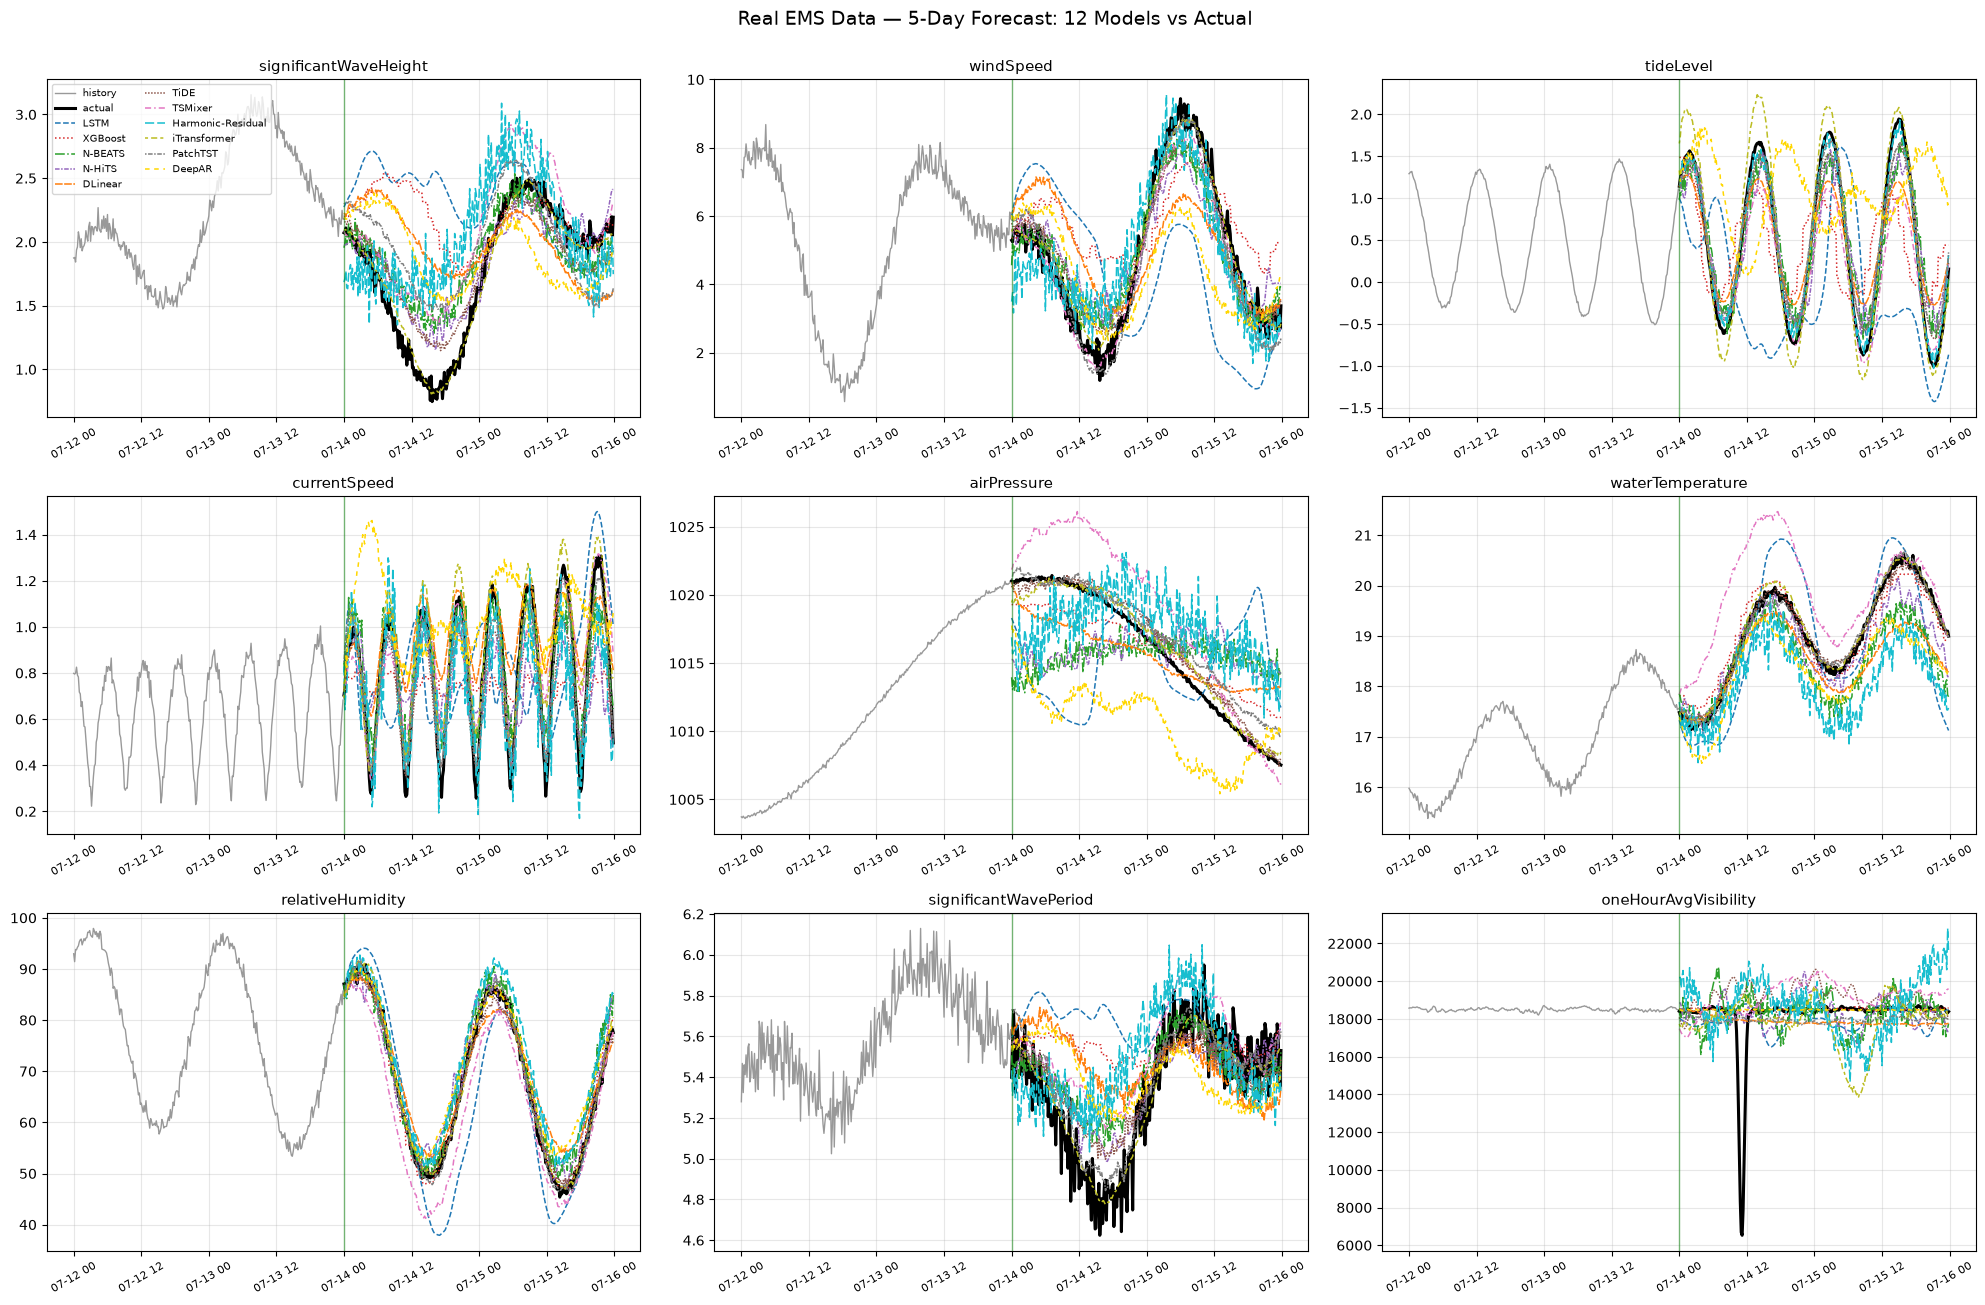

In [25]:
hist_tail = df_num_full.iloc[-HORIZON - LOOKBACK:-HORIZON]
key_plots = ["significantWaveHeight", "windSpeed", "tideLevel", "currentSpeed",
             "airPressure", "waterTemperature", "relativeHumidity",
             "significantWavePeriod", "oneHourAvgVisibility"]
styles = {
    "LSTM": ("tab:blue", "--"), "XGBoost": ("tab:red", ":"),
    "N-BEATS": ("tab:green", "-."), "N-HiTS": ("tab:purple", (0, (3, 1, 1, 1))),
    "DLinear": ("tab:orange", (0, (5, 1))), "TiDE": ("tab:brown", (0, (1, 1))),
    "TSMixer": ("tab:pink", (0, (4, 2, 1, 2))), "Harmonic-Residual": ("tab:cyan", (0, (6, 2))),
    "iTransformer": ("tab:olive", (0, (2, 2, 4, 2))), "PatchTST": ("tab:gray", (0, (1, 1, 3, 1))),
    "DeepAR": ("gold", (0, (3, 3))),
}

fig, axes = plt.subplots(3, 3, figsize=(20, 13))
for ax, p in zip(axes.ravel(), key_plots):
    ax.plot(hist_tail.index, hist_tail[p], color="0.6", lw=1, label="history")
    ax.plot(truth.index, truth[p], color="black", lw=2.2, label="actual")
    for name, pred_df in MODELS.items():
        c, ls = styles[name]
        ax.plot(truth.index, pred_df[p], color=c, lw=1.1, ls=ls, label=name)
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(p, fontsize=11); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
axes.ravel()[0].legend(fontsize=7, loc="upper left", ncol=2)
fig.suptitle("Real EMS Data — 5-Day Forecast: 12 Models vs Actual", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig("forecast_plots_realdata.png", dpi=110, bbox_inches="tight")
plt.show()


## 18. Save outputs for the results dashboard

In [26]:
fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    for name, pred_df in MODELS.items():
        fva[f"{p}__{name.lower().replace('-', '').replace(' ', '')}"] = pred_df[p].values
fva.to_csv("forecast_vs_actual_realdata.csv", index=False)

unc = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    if p in CIRCULAR_PARAMS:
        continue
    unc[f"{p}__actual"] = truth[p].values
    unc[f"{p}__deepar_mean"] = deepar_final[p].values
    unc[f"{p}__deepar_std"] = deepar_std_df[p].values if p in deepar_std_df.columns else np.nan
unc.to_csv("uncertainty_bands_realdata.csv", index=False)

print("Saved: metrics_summary_realdata.csv, forecast_vs_actual_realdata.csv, "
      "uncertainty_bands_realdata.csv, forecast_plots_realdata.png")


Saved: metrics_summary_realdata.csv, forecast_vs_actual_realdata.csv, uncertainty_bands_realdata.csv, forecast_plots_realdata.png


## 19. Best model per parameter (ranked)

In [27]:
def best_skill_value(row):
    return row[f"{row['best_model']}_skill_%"]

ranking_df = metrics_df.copy()
ranking_df["best_skill_%"] = ranking_df.apply(best_skill_value, axis=1)
ranking_df = ranking_df.sort_values("best_skill_%", ascending=False)
ranking_cols = ["parameter", "best_model", "best_skill_%"] + [f"{m}_MAE" for m in MODELS]
ranking_df = ranking_df[ranking_cols].reset_index(drop=True)
ranking_df.insert(0, "rank", ranking_df.index + 1)
ranking_df.to_csv("best_model_per_parameter_realdata.csv", index=False)
ranking_df


,rank,parameter,best_model,best_skill_%,LSTM_MAE,XGBoost_MAE,N-BEATS_MAE,N-HiTS_MAE,DLinear_MAE,TiDE_MAE,TSMixer_MAE,Harmonic-Residual_MAE,iTransformer_MAE,PatchTST_MAE,DeepAR_MAE
0,1,airTemperature,iTransformer,96.3,1.9449,0.3981,0.8858,0.8891,1.1281,0.4096,1.5523,1.3275,0.2160,0.2553,0.9747
1,2,currentDirection,DLinear,96.3,87.6947,43.1120,10.4180,16.9756,3.4257,3.4817,6.3238,7.7739,4.3877,4.0978,100.6767
2,3,windDirection,iTransformer,95.5,82.6002,20.6642,32.9146,20.9739,38.9151,6.9035,26.6025,37.3941,3.2891,3.3205,41.1585
3,4,relativeHumidity,PatchTST,94.7,6.2874,1.3304,2.9702,2.7263,3.4053,1.4977,5.1292,4.3667,1.0341,0.9950,3.2334
4,5,waterTemperature,iTransformer,93.6,0.6499,0.2537,0.5730,0.3333,0.5416,0.1037,0.8728,0.9616,0.0984,0.1091,0.7259
5,6,dewPointTemperature,iTransformer,92.8,0.7005,0.2383,0.3427,0.3445,0.4301,0.1873,0.5805,0.4732,0.1519,0.2309,0.3946
6,7,globalRadiation,XGBoost,92.1,95.8507,18.9345,39.7706,76.6541,96.8650,32.9554,46.9097,20.1194,31.8705,24.0480,71.2981
7,8,tideLevel,Harmonic-Residual,91.1,1.0329,0.5703,0.2591,0.2827,0.3409,0.1676,0.2979,0.0823,0.2137,0.1640,1.0866
8,9,airPressure,iTransformer,87.6,5.0681,1.7697,4.2941,4.1944,2.3747,0.7988,3.0130,3.8112,0.6354,1.1932,5.6755
9,10,significantWaveHeight,iTransformer,86.6,0.6643,0.4655,0.2600,0.1988,0.5024,0.2023,0.3247,0.4202,0.0674,0.3856,0.4783


## 20. Two-model ensembles — can combining models beat the single best?

Same leakage-free, unweighted-average methodology as the synthetic notebook (now with
3 circular parameters using vector-averaging instead of 1).

In [28]:
from itertools import combinations

def circular_mean_deg(deg_arrays):
    rad = np.deg2rad(np.stack(deg_arrays, axis=0))
    sin_mean = np.sin(rad).mean(axis=0)
    cos_mean = np.cos(rad).mean(axis=0)
    return np.rad2deg(np.arctan2(sin_mean, cos_mean)) % 360

model_names = list(MODELS.keys())
ensemble_rows, ensemble_series = [], {}

for p in report_params:
    yt = truth[p].values
    is_circular = p in CIRCULAR_PARAMS
    yp_persist = np.repeat(last_obs[p], HORIZON)
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)

    row = metrics_df[metrics_df["parameter"] == p].iloc[0]
    single_best_model = row["best_model"]
    single_best_mae = row[f"{single_best_model}_MAE"]

    best_pair, best_pair_mae, best_pair_series = None, np.inf, None
    for m1, m2 in combinations(model_names, 2):
        pred1, pred2 = MODELS[m1][p].values, MODELS[m2][p].values
        if is_circular:
            ens = circular_mean_deg([pred1, pred2])
            mae = circ_mae(yt, ens)
        else:
            ens = (pred1 + pred2) / 2.0
            mae = mean_absolute_error(yt, ens)
        if mae < best_pair_mae:
            best_pair, best_pair_mae, best_pair_series = (m1, m2), mae, ens

    best_pair_skill = (1 - best_pair_mae / mae_p) * 100 if mae_p > 0 else np.nan
    improvement = single_best_mae - best_pair_mae
    recommended = best_pair_mae < single_best_mae - 1e-9

    ensemble_series[p] = best_pair_series
    ensemble_rows.append({
        "parameter": p, "single_best_model": single_best_model,
        "single_best_MAE": round(single_best_mae, 4),
        "best_ensemble_pair": f"{best_pair[0]} + {best_pair[1]}",
        "ensemble_MAE": round(best_pair_mae, 4), "ensemble_skill_%": round(best_pair_skill, 1),
        "improvement_vs_single_best": round(improvement, 4),
        "recommended_ensemble": bool(recommended),
    })

ensemble_df = pd.DataFrame(ensemble_rows).sort_values("improvement_vs_single_best", ascending=False)
ensemble_df.to_csv("ensemble_recommendation_realdata.csv", index=False)
print(f"Ensembling helps on {ensemble_df['recommended_ensemble'].sum()} / {len(ensemble_df)} parameters.")
ensemble_df


Ensembling helps on 16 / 24 parameters.


,parameter,single_best_model,single_best_MAE,best_ensemble_pair,ensemble_MAE,ensemble_skill_%,improvement_vs_single_best,recommended_ensemble
20,twentyFourHourAvgVisibility,PatchTST,254.3434,XGBoost + PatchTST,225.4662,25.3,28.8772,True
18,tenMinuteAvgVisibility,DeepAR,454.2392,XGBoost + DeepAR,448.8296,17.6,5.4096,True
5,globalRadiation,XGBoost,18.9345,XGBoost + Harmonic-Residual,17.0658,92.9,1.8687,True
21,windDirection,iTransformer,3.2891,iTransformer + PatchTST,2.9376,96.0,0.3515,True
2,relativeHumidity,PatchTST,0.9950,iTransformer + PatchTST,0.8557,95.4,0.1393,True
11,conductivity,iTransformer,0.2397,iTransformer + PatchTST,0.1590,79.1,0.0807,True
4,windSpeed,iTransformer,0.3297,TSMixer + iTransformer,0.2856,86.6,0.0441,True
10,waterTemperature,iTransformer,0.0984,iTransformer + PatchTST,0.0754,95.1,0.0230,True
0,airTemperature,iTransformer,0.2160,iTransformer + PatchTST,0.1973,96.6,0.0187,True
22,currentDirection,DLinear,3.4257,DLinear + TiDE,3.4107,96.3,0.0150,True


In [29]:
ens_fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    ens_fva[f"{p}__actual"] = truth[p].values
    ens_fva[f"{p}__ensemble"] = ensemble_series[p]
ens_fva.to_csv("ensemble_forecast_vs_actual_realdata.csv", index=False)
print("Saved: best_model_per_parameter_realdata.csv, ensemble_recommendation_realdata.csv, "
      "ensemble_forecast_vs_actual_realdata.csv")


Saved: best_model_per_parameter_realdata.csv, ensemble_recommendation_realdata.csv, ensemble_forecast_vs_actual_realdata.csv


## 21. PrecipitationType classifier (XGBoost multiclass)

`precipitationType` (NONE / DRIZZLE / RAIN) can't enter the regression pipeline above —
it's categorical. A separate multiclass XGBoost classifier predicts it directly,
using the same lag + lead-time + calendar feature recipe as the XGBoost regressor.
Class weights compensate for the heavy `NONE` imbalance (~97% of all 10-min bins).

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_cat["precip_code"] = le.fit_transform(df_cat["precipitationType"])
print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))
print(df_cat["precipitationType"].value_counts())

cat_train = df_cat["precip_code"].iloc[:-HORIZON]
cat_test = df_cat["precipitationType"].iloc[-HORIZON:]

PRECIP_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 144]

def make_classifier_training(scaled, cat_series, calendar_cols, lags, horizon, origin_step=16):
    n, max_lag = len(scaled), max(lags)
    feats, labels = [], []
    cat_vals = cat_series.values
    for origin in range(max_lag, n - horizon, origin_step):
        base = {f"precip_lag{L}": cat_vals[origin - L] for L in lags}
        for c in ["airPressure", "relativeHumidity", "globalRadiation"]:
            for L in [1, 6, 24]:
                base[f"{c}_lag{L}"] = scaled[c].iloc[origin - L]
        for h in range(1, horizon + 1, 2):
            row = dict(base); row["lead_h"] = h
            for cc in calendar_cols:
                row[cc] = scaled[cc].iloc[origin + h]
            feats.append(row)
            labels.append(cat_vals[origin + h])
    return pd.DataFrame(feats), np.array(labels)

X_clf, y_clf = make_classifier_training(train_scaled, cat_train, calendar_cols, PRECIP_LAGS, HORIZON)
print(f"Classifier training rows: {X_clf.shape[0]:,}  features: {X_clf.shape[1]}")

clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.06, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=4, objective="multi:softprob", num_class=len(le.classes_),
    eval_metric="mlogloss",
)
sample_weight = np.where(y_clf == le.transform(["NONE"])[0], 1.0, 15.0)   # upweight rare classes
clf.fit(X_clf, y_clf, sample_weight=sample_weight)
print("Trained precipitationType classifier.")


Classes: {'DRIZZLE': 0, 'NONE': 1, 'RAIN': 2}
precipitationType
NONE       4185
DRIZZLE      78
RAIN         57
Name: count, dtype: int64


Classifier training rows: 32,400  features: 23


Trained precipitationType classifier.


In [31]:
origin_idx_c = len(train_scaled) - 1
base_row_c = {f"precip_lag{L}": cat_train.values[origin_idx_c - (L - 1)] for L in PRECIP_LAGS}
for c in ["airPressure", "relativeHumidity", "globalRadiation"]:
    for L in [1, 6, 24]:
        base_row_c[f"{c}_lag{L}"] = train_scaled[c].iloc[origin_idx_c - (L - 1)]

pred_rows_c = []
for h in range(1, HORIZON + 1):
    ts = test_df.index[h - 1]
    row = dict(base_row_c); row["lead_h"] = h
    for cc in calendar_cols:
        row[cc] = full_scaled.loc[ts, cc]
    pred_rows_c.append(row)
X_fore_c = pd.DataFrame(pred_rows_c)[list(X_clf.columns)]

precip_pred_code = clf.predict(X_fore_c)
precip_pred = le.inverse_transform(precip_pred_code)

print("Classification report (48h held-out forecast):")
print(classification_report(cat_test.values, precip_pred, zero_division=0))
f1_macro = f1_score(cat_test.values, precip_pred, average="macro", zero_division=0)
print(f"Macro F1: {f1_macro:.3f}")

precip_df = pd.DataFrame({"timestamp": test_df.index, "actual": cat_test.values, "predicted": precip_pred})
precip_df.to_csv("precipitation_type_forecast.csv", index=False)
print("Saved: precipitation_type_forecast.csv")


Classification report (48h held-out forecast):
              precision    recall  f1-score   support

     DRIZZLE       0.00      0.00      0.00         2
        NONE       0.97      1.00      0.99       280
        RAIN       0.00      0.00      0.00         6

    accuracy                           0.97       288
   macro avg       0.32      0.33      0.33       288
weighted avg       0.95      0.97      0.96       288

Macro F1: 0.329
Saved: precipitation_type_forecast.csv


## 22. Duplicate reconstruction sanity check

Confirms the 6 dropped duplicates reconstruct cleanly from their kept twin's **forecast**
(not just the training fit) — i.e. the linear reconstruction generalizes to the 48h
held-out forecast, not only the training window.

In [32]:
print("Duplicate reconstruction error on the held-out forecast (using each model's own prediction):")
for keep, drop in DUPLICATES:
    keep_model, slope, intercept, r2_train = recon_coef[drop]
    true_drop = df_10min[drop].iloc[-HORIZON:]
    # Use the single best model's forecast of the kept twin to reconstruct the duplicate
    best_for_keep = metrics_df.set_index("parameter").loc[keep, "best_model"]
    recon_pred = slope * MODELS[best_for_keep][keep].values + intercept
    mae = mean_absolute_error(true_drop.values, recon_pred)
    print(f"  {drop:25s} (from {keep}'s {best_for_keep} forecast)  train_R2={r2_train:.5f}  "
          f"held-out reconstruction MAE={mae:.4f}")


Duplicate reconstruction error on the held-out forecast (using each model's own prediction):
  windChillTemperature      (from airTemperature's iTransformer forecast)  train_R2=1.00000  held-out reconstruction MAE=0.2160
  tidePressure              (from tideLevel's Harmonic-Residual forecast)  train_R2=0.99976  held-out reconstruction MAE=32.6981
  waterPressure             (from tideLevel's Harmonic-Residual forecast)  train_R2=0.99992  held-out reconstruction MAE=8.3946
  waterLevel                (from tideLevel's Harmonic-Residual forecast)  train_R2=0.99528  held-out reconstruction MAE=0.0231
  waterTemperature_WQ       (from waterTemperature's iTransformer forecast)  train_R2=0.99985  held-out reconstruction MAE=0.0980
  maxWaveHeight             (from significantWaveHeight's iTransformer forecast)  train_R2=0.99907  held-out reconstruction MAE=0.1114


## 23. How to read the results

This real-data run answers the question the synthetic notebook couldn't: **does the
correlation-block structure the assignment doc identified actually translate into which
models win?**

- **Thermal/moisture block** (`airTemperature`, `relativeHumidity`, `dewPointTemperature`,
  `waterTemperature`, r = 0.75-0.985): expect TSMixer/iTransformer/TiDE (cross-parameter
  models) to outperform channel-independent models here more clearly than in the
  synthetic data, where coupling was weaker.
- **Wave block** (`significantWaveHeight`, `significantWavePeriod`, `peakWaveEnergyPeriod`,
  `zeroCrossingPeriod`, r = 0.71-0.86): same expectation — PatchTST/TSMixer should benefit
  from the explicit relationship between wave height and period.
- **Tidal/level block** (`tideLevel`, `currentDirection`, r = -0.86 anti-correlated):
  Harmonic-Residual should dominate `tideLevel` even more decisively than in the
  synthetic data, since this is **real tidal physics**, not a synthetic approximation of it.
- **Visibility block** (the three short-window visibility measures, r = 0.90-0.94):
  near-duplicate enough that any reasonable model should do well on all three once it
  does well on one.
- **Weakly-correlated parameters** (`windSpeed`, `globalRadiation`,
  `twentyFourHourAvgVisibility`, `precipitationDifference`, `salinity`, `airPressure`,
  `precipitationIntensity`, `compass`, `windDirection`, `currentSpeed`): per the
  assignment doc's heuristic these should favor XGBoost or any channel-independent model
  equally — cross-parameter structure has nothing to contribute here, so the simplest
  competent model should win, matching the synthetic notebook's general finding that
  DLinear/PatchTST do as well or better than heavier cross-parameter models when there's
  no real correlation to exploit.

Compare `best_model_per_parameter_realdata.csv` against these predictions to check
whether the doc's correlation analysis is actually predictive of model choice on real
data, not just descriptive of the correlation matrix.

### Using this in production
Replace `Simulation_30days_Data_31parameters.xlsx` with live EMS sensor exports (same 31
columns, 1-minute cadence) and re-run from §1. Re-validate before operational use — 30
days is still a thin training set for reliable medium-range forecasting; collect more history before
trusting this in a real mooring/docking decision pipeline.
